# Move this file to project root to test

In [1]:
from dopplerguesser.predict.fetch_tles import fetch_tles
from dopplerguesser.predict.filters import filter_visibility, filter_heo, filter_geostationary, filter_by_doppler, filter_constellations, filter_by_epoch, filter_debris
from dopplerguesser.predict.matcher import score_candidates
from dopplerguesser.predict.observer import Observer
from dopplerguesser.predict.satellite import Satellite
from dopplerguesser.predict.propagator import propagate_earth_rotation, propagate_fg_elliptic
from dopplerguesser.misc.curve_generator import generate_doppler_curve
from matplotlib import pyplot as plt

In [2]:
from time import perf_counter
from datetime import datetime
from datetime import timezone

In [3]:
observer = Observer(lat=55.7558, lon=37.6176, alt=200)  # Moscow

In [4]:
now = datetime.now(tz=timezone.utc)
print(now)
ts = now.timestamp()
print(ts)

2026-02-20 15:14:16.857265+00:00
1771600456.857265


In [5]:
fetched_tles = fetch_tles(ts)
print(f"Fetched {len(fetched_tles)} TLEs")

Fetched 29733 TLEs


In [6]:
# with open('activesatellites.txt', 'w') as f:
#     for sat in fetched_tles:
#         f.write(f"{sat.satellite.name}\n")

In [7]:
# Filtering
print('Initial length:', len(fetched_tles))

t1 = perf_counter()
satellites = filter_constellations(fetched_tles, constellations_to_remove=['starlink', 'oneweb'])
t2 = perf_counter()
print('After constellation filter:', len(satellites))
print('Took {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_debris(satellites)
t2 = perf_counter()
print('After debris filter:', len(satellites))
print('Took {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_by_epoch(satellites, maxage=14)
t2 = perf_counter()
print('After epoch filter:', len(satellites))
print('Took {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_geostationary(satellites)
t2 = perf_counter()
print('After geostationary filter:', len(satellites))
print('Took {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_heo(satellites)
t2 = perf_counter()
print('After HEO filter:', len(satellites))
print('Took: {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_visibility(satellites, observer, ts, min_elevation=0.0)
t2 = perf_counter()
print('After visibility filter:', len(satellites))
print('Took: {:.3f} seconds\n'.format(t2 - t1))

Initial length: 29733
After constellation filter: 19454
Took 0.007 seconds

After debris filter: 9900
Took 0.004 seconds

After epoch filter: 9599
Took 0.080 seconds

After geostationary filter: 6595
Took 0.003 seconds

After HEO filter: 6529
Took: 0.001 seconds

After visibility filter: 456
Took: 0.171 seconds



In [8]:
# Earth rotation Propagation
t1 = perf_counter()
observer.compute_track(ts)
t2 = perf_counter()
print('Earth rotation propagation took {:.3f} seconds\n'.format(t2 - t1))

Earth rotation propagation took 0.004 seconds



In [9]:
# Satellite propagation
t1 = perf_counter()
for sat in satellites:
    sat.compute_initial_state(ts)
t2 = perf_counter()
print('Satellite propagation took {:.3f} seconds\n'.format(t2 - t1))

Satellite propagation took 0.037 seconds



TEMPSAT 1
[(np.int64(0), np.float64(2199958402.953029)), (np.int64(1), np.float64(2199958387.10684)), (np.int64(2), np.float64(2199958371.372573)), (np.int64(3), np.float64(2199958355.7496595)), (np.int64(4), np.float64(2199958340.2375374)), (np.int64(5), np.float64(2199958324.835646)), (np.int64(6), np.float64(2199958309.5434294)), (np.int64(7), np.float64(2199958294.3603344)), (np.int64(8), np.float64(2199958279.285812)), (np.int64(9), np.float64(2199958264.319316)), (np.int64(10), np.float64(2199958249.460304)), (np.int64(11), np.float64(2199958234.708237)), (np.int64(12), np.float64(2199958220.0625796)), (np.int64(13), np.float64(2199958205.5227995)), (np.int64(14), np.float64(2199958191.0883684)), (np.int64(15), np.float64(2199958176.7587595)), (np.int64(16), np.float64(2199958162.533452)), (np.int64(17), np.float64(2199958148.4119267)), (np.int64(18), np.float64(2199958134.3936677)), (np.int64(19), np.float64(2199958120.478163)), (np.int64(20), np.float64(2199958106.664903)), (np

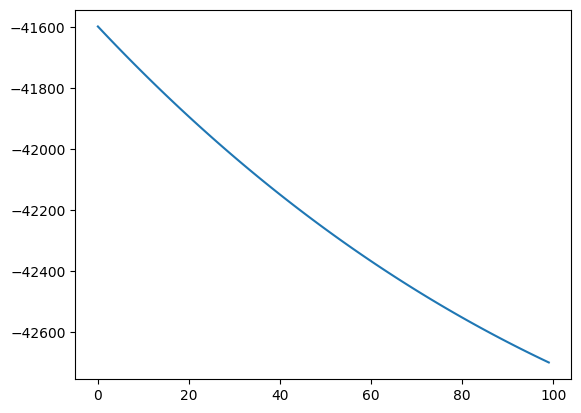

In [10]:
# Mock doppler curve generation
unknownsatellite = satellites[0]
freq = 2.2e9
print(unknownsatellite.satellite.name)
curve = generate_doppler_curve(unknownsatellite, observer, freq, ts, duration=100, step=1, simulated_noise=0)
print(curve)

curveclean = [(x, y - freq) for x, y in curve]

plt.plot(*zip(*curveclean))
plt.show()

In [ ]:
# Apply Doppler filter
if False:
    t1 = perf_counter()
    satellites = filter_by_doppler(satellites, observer, ts, freq, curve[0][1])
    t2 = perf_counter()
    print('After Doppler filter:', len(satellites))
    print('Took: {:.3f} seconds\n'.format(t2 - t1))
    print('Remaining candidates:')
    for sat in satellites:
        print(sat.satellite.name)

After Doppler filter: 32
Took: 0.003 seconds

Remaining candidates:
TEMPSAT 1
WNISAT-1
IRIDIUM 122
STEP CUBE LAB-II
TIANMU-1 11
HULIANWANG DIGUI-19
KUIPER-00074
HULIANWANG DIGUI-70
COSMOS 2597 (RODNIK-S *)
CONNECTA IOT-13
THOR AGENA B R/B
TEMPSAT 1
NAVSPASUR ROD 1
METEOR 1-11
COSMOS 626
COSMOS 823
COSMOS 951
COSMOS 1019
COSMOS 1135
COSMOS 1308
COSMOS 1365 FUEL CORE
COSMOS 1598
COSMOS 2191
COSMOS 2228
COSMOS 2247
SERVIS 1
GONETS D1M 1
PSLV R/B
CZ-4C R/B
CZ-6A R/B
TBA - TO BE ASSIGNED
StarSh


In [12]:
# Propagate candidates using FG elliptic model
t1 = perf_counter()
for sat in satellites:
    sat.compute_track(ts)
t2 = perf_counter()
print('FG elliptic propagation took {:.3f} seconds\n'.format(t2 - t1))

FG elliptic propagation took 0.364 seconds



In [13]:
# Score candidates
t1 = perf_counter()
scored_candidates = score_candidates(satellites, curve, freq, observer)
t2 = perf_counter()
print('\nScoring took {:.3f} seconds\n'.format(t2 - t1))
for sat, rmse in scored_candidates:
    print(f'{sat.satellite.name}: {rmse:.6f}')


Scoring took 0.043 seconds

TEMPSAT 1: 1.240032
TEMPSAT 1: 1.240032
COSMOS 1365 FUEL CORE: 18.656283
COSMOS 1308: 25.551720
COSMOS 1019: 33.336523
SERVIS 1: 34.118486
COSMOS 823: 57.161478
COSMOS 1598: 62.337577
THOR AGENA B R/B: 78.815675
HULIANWANG DIGUI-19: 89.682556
COSMOS 1135: 114.458283
NAVSPASUR ROD 1: 121.671430
COSMOS 2597 (RODNIK-S *): 204.134817
KUIPER-00074: 209.211500
GONETS D1M 1: 218.143073
CZ-4C R/B: 234.400496
COSMOS 2191: 278.144479
CZ-6A R/B: 280.877487
COSMOS 2247: 317.721963
IRIDIUM 122: 338.069477
COSMOS 626: 347.247798
COSMOS 951: 499.860400
HULIANWANG DIGUI-70: 555.343744
TBA - TO BE ASSIGNED: 685.686485
STEP CUBE LAB-II: 725.323045
StarSh: 947.071748
METEOR 1-11: 1009.513922
PSLV R/B: 1058.808882
WNISAT-1: 1167.108366
CONNECTA IOT-13: 1490.667902
COSMOS 2228: 1498.842447
TIANMU-1 11: 1924.114842
